In [1]:
import sys, importlib, os, inspect
import importlib

NEW_ROOT = "/blue_npadillacoreano/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory"
OLD_ROOT = "/blue/npadillacoreano/t.heeps/rehouse_code/ephys_analysis"

os.chdir('/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys') # seems to be the only real fix

# Printing the search path to see what it's looking at
# print(sys.path)

# 4) Re-import and verify
import behavior.boris_extraction as boris
import lfp.lfp_analysis.LFP_collection as LFP_collection
import trodes.read_exported as tr

import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path

# importing ephys analysis code
# import trodes.read_exported as tr
# import behavior.boris_extraction as boris

print("behavior package from:", boris.__file__)
print("boris_extraction from:", inspect.getfile(boris))
print("trodes read_exported from: ", inspect.getfile(tr))
# from LFP.lfp_collection import LFPCollection

/blue/npadillacoreano/t.heeps/.conda/envs/lfp_export_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


behavior package from: /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/behavior/boris_extraction.py
boris_extraction from: /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/behavior/boris_extraction.py
trodes read_exported from:  /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/trodes/read_exported.py


In [2]:
pd.set_option('display.max_colwidth', 0)  # 0 means unlimited in newer pandas versions

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column contents
pd.set_option("display.max_colwidth", None)

# Expand the display to the full width of the screen
pd.set_option("display.width", 0)


### Mapping of subjects to the videotimestamps

In [3]:
merge_to_video = {
    "22_rehouse_d0_merged.time": "22_23_rehouse_d0.2.videoTimeStamps",
    "23_rehouse_d0_merged.time": "22_23_rehouse_d0.1.videoTimeStamps",
    "22_rehouse_d1_merged.time": "22_23_rehouse_d1.1.videoTimeStamps",
    "23_rehouse_d1_merged.time": "22_23_rehouse_d1.2.videoTimeStamps",
    "22_rehouse_d3_merged.time": "22_23_rehouse_d3.2.videoTimeStamps",
    "23_rehouse_d3_merged.time": "22_23_rehouse_d3.1.videoTimeStamps",
    "22_rehouse_d4_merged.time": "22_23_rehouse_d4.2.videoTimeStamps",
    "23_rehouse_d4_merged.time": "22_23_rehouse_d4.1.videoTimeStamps",
    "22_rehouse_d5_merged.time": "22_23_rehouse_d5.2.videoTimeStamps",
    "23_rehouse_d5_merged.time": "22_23_rehouse_d5.1.videoTimeStamps",
    "22_rehouse_d6_merged.time": "22_23_rehouse_d6.2.videoTimeStamps",
    "23_rehouse_d6_merged.time": "22_23_rehouse_d6.1.videoTimeStamps",
    "22_rehouse_d7_merged.time": "22_23_rehouse_d7.2.videoTimeStamps",
    "23_rehouse_d7_merged.time": "22_23_rehouse_d7.1.videoTimeStamps",
    "31_rehouse_d0_merged.time": "31_32_rehouse_d0.1.videoTimeStamps",
    "32_rehouse_d0_merged.time": "31_32_rehouse_d0.2.videoTimeStamps",
    "31_rehouse_d1_merged.time": "31_32_rehouse_d1.2.videoTimeStamps",
    "32_rehouse_d1_merged.time": "31_32_rehouse_d1.1.videoTimeStamps",
    "31_rehouse_d2_merged.time": "31_32_rehouse_d2.2.videoTimeStamps",
    "32_rehouse_d2_merged.time": "31_32_rehouse_d2.1.videoTimeStamps",
    "31_rehouse_d3_merged.time": "31_32_rehouse_d3.2.videoTimeStamps",
    "32_rehouse_d3_merged.time": "31_32_rehouse_d3.1.videoTimeStamps",
    "31_rehouse_d4_merged.time": "31_32_rehouse_d4.2.videoTimeStamps",
    "32_rehouse_d4_merged.time": "31_32_rehouse_d4.1.videoTimeStamps",
    "31_rehouse_d5_merged.time": "31_32_rehouse_d5.2.videoTimeStamps",
    "32_rehouse_d5_merged.time": "31_32_rehouse_d5.1.videoTimeStamps",
    "31_rehouse_d6_merged.time": "31_32_rehouse_d6.2.videoTimeStamps",
    "32_rehouse_d6_merged.time": "31_32_rehouse_d6.1.videoTimeStamps",
    "31_rehouse_d7_merged.time": "31_32_rehouse_d7.2.videoTimeStamps",
    "32_rehouse_d7_merged.time": "31_32_rehouse_d7.1.videoTimeStamps",
    "41_rehouse_d0_merged.time": "41_44_rehouse_d0.2.videoTimeStamps",
    "44_rehouse_d0_merged.time": "41_44_rehouse_d0.1.videoTimeStamps",
    "41_rehouse_d1_merged.time": "41_44_rehouse_d1.2.videoTimeStamps",
    "44_rehouse_d1_merged.time": "41_44_rehouse_d1.1.videoTimeStamps",
    "41_rehouse_d2_merged.time": "41_44_rehouse_d2.2.videoTimeStamps",
    "44_rehouse_d2_merged.time": "41_44_rehouse_d2.1.videoTimeStamps",
    "41_rehouse_d3_merged.time": "41_44_rehouse_d3.1.videoTimeStamps",
    "44_rehouse_d3_merged.time": "41_44_rehouse_d3.2.videoTimeStamps",
    "41_rehouse_d4_merged.time": "41_44_rehouse_d4.2.videoTimeStamps",
    "44_rehouse_d4_merged.time": "41_44_rehouse_d4.1.videoTimeStamps",
    "41_rehouse_d5_merged.time": "41_44_rehouse_d5.2.videoTimeStamps",
    "44_rehouse_d5_merged.time": "41_44_rehouse_d5.1.videoTimeStamps",
    "41_rehouse_d6_merged.time": "41_44_rehouse_d6.2.videoTimeStamps",
    "44_rehouse_d6_merged.time": "41_44_rehouse_d6.1.videoTimeStamps",
    "41_rehouse_d7_merged.time": "41_44_rehouse_d7.2.videoTimeStamps",
    "44_rehouse_d7_merged.time": "41_44_rehouse_d7.1.videoTimeStamps"
}

In [4]:
rec_to_timefile = {
    "41_rehouse_d0_merged.rec": "41_rehouse_d0_merged.time",
    "41_rehouse_d7_merged.rec": "41_rehouse_d7_merged.time",
    "44_rehouse_d0_merged.rec": "44_rehouse_d0_merged.time",
    "44_rehouse_d7_merged.rec": "44_rehouse_d7_merged.time",
}

In [5]:
d0_41_beh_path = r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/behavior_csvs/aggregated_csvs/41_rehouse_d0_OM.csv'
d7_41_beh_path = r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/behavior_csvs/aggregated_csvs/41_rehouse_d7_MO.csv'

d0_44_beh_path = r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/behavior_csvs/aggregated_csvs/44_rehouse_d0_MO.csv'
d7_44_beh_path = r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/behavior_csvs/aggregated_csvs/44_rehouse_d7_OM.csv'

### data_path to folder with all raw lfp recs, used in lfp collection creation later 

In [6]:
data_path = r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/raw_lfp_data'

In [7]:
# subj 41 day0 behaviors
d0_41_beh = pd.read_csv(d0_41_beh_path)
d0_41_subj_beh = d0_41_beh[d0_41_beh['Subject'] == 'subject']

# subj 41 day 7 behaviors
d7_41_beh = pd.read_csv(d7_41_beh_path)
d7_41_subj_beh = d7_41_beh[d7_41_beh['Subject'] == 'subject']

# subj 44 day 0 behaviors
d0_44_beh = pd.read_csv(d0_44_beh_path)
d0_44_subj_beh = d0_44_beh[d0_44_beh['Subject'] == 'subject']

# subj 44 day 7 behaviors
d7_44_beh = pd.read_csv(d7_44_beh_path)
d7_44_subj_beh = d7_44_beh[d7_44_beh['Subject'] == 'subject']

d0_41_subj_beh.head()

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
0,41_rehouse_d0_OM,2025-04-01 08:42:06.525,NaN,Media file,player #1:C:/Users/adria/OneDrive/Desktop/Padilla Coreano Lab/BORIS/Observations/41_rehouse_d0_converted.mp4,0.0,1182.134,1801.267,15.0,subject,205.854,mice back in,Not defined,POINT,603.533,603.533,NaN,C:/Users/adria/OneDrive/Desktop/Padilla Coreano Lab/BORIS/Observations/41_rehouse_d0_converted.mp4,9053,9053.0,NaN,NaN,NaN,NaN
1,41_rehouse_d0_OM,2025-04-01 08:42:06.525,NaN,Media file,player #1:C:/Users/adria/OneDrive/Desktop/Padilla Coreano Lab/BORIS/Observations/41_rehouse_d0_converted.mp4,0.0,1182.134,1801.267,15.0,subject,205.854,sniffing object,Not defined,STATE,603.667,612.267,8.600,C:/Users/adria/OneDrive/Desktop/Padilla Coreano Lab/BORIS/Observations/41_rehouse_d0_converted.mp4,9055,9184.0,NaN,NaN,NaN,NaN
2,41_rehouse_d0_OM,2025-04-01 08:42:06.525,NaN,Media file,player #1:C:/Users/adria/OneDrive/Desktop/Padilla Coreano Lab/BORIS/Observations/41_rehouse_d0_converted.mp4,0.0,1182.134,1801.267,15.0,subject,205.854,sniffing object,Not defined,STATE,613.733,618.533,4.800,C:/Users/adria/OneDrive/Desktop/Padilla Coreano Lab/BORIS/Observations/41_rehouse_d0_converted.mp4,9206,9278.0,NaN,NaN,NaN,NaN
3,41_rehouse_d0_OM,2025-04-01 08:42:06.525,NaN,Media file,player #1:C:/Users/adria/OneDrive/Desktop/Padilla Coreano Lab/BORIS/Observations/41_rehouse_d0_converted.mp4,0.0,1182.134,1801.267,15.0,subject,205.854,sniffing object,Not defined,STATE,620.067,622.600,2.533,C:/Users/adria/OneDrive/Desktop/Padilla Coreano Lab/BORIS/Observations/41_rehouse_d0_converted.mp4,9301,9339.0,NaN,NaN,NaN,NaN
4,41_rehouse_d0_OM,2025-04-01 08:42:06.525,NaN,Media file,player #1:C:/Users/adria/OneDrive/Desktop/Padilla Coreano Lab/BORIS/Observations/41_rehouse_d0_converted.mp4,0.0,1182.134,1801.267,15.0,subject,205.854,sniffing object,Not defined,STATE,625.333,632.600,7.267,C:/Users/adria/OneDrive/Desktop/Padilla Coreano Lab/BORIS/Observations/41_rehouse_d0_converted.mp4,9380,9489.0,NaN,NaN,NaN,NaN


# Creating Behavior Dicts for LFP Collection

### Aligning Boris to Neural Data

In [9]:
d0_41_beh.columns

Index(['Observation id', 'Observation date', 'Description', 'Observation type',
       'Source', 'Time offset (s)', 'Coding duration', 'Media duration (s)',
       'FPS (frame/s)', 'Subject',
       'Observation duration by subject by observation', 'Behavior',
       'Behavioral category', 'Behavior type', 'Start (s)', 'Stop (s)',
       'Duration (s)', 'Media file name', 'Image index start',
       'Image index stop', 'Image file path start', 'Image file path stop',
       'Comment start', 'Comment stop'],
      dtype='object')

In [10]:
list(d0_41_beh['Behavior'].unique())

['mice back in',
 'sniffing object',
 'mice taken out',
 'facial sniffing',
 'anogenital sniffing']

#### Helper functions to read from trodes and .videotimestamps and then align them to play

In [11]:
first_timestamp_dict = {}

# Step 1: extract first_timestamp from all *.dat file
def build_first_ts_dict(data_path):
    for dirpath, dirnames, filenames in os.walk(data_path):
        if os.path.basename(dirpath).endswith('.time'):
            for file in filenames:
                if file.endswith(".dat"):
                    ts_file = os.path.join(dirpath, file)
                    ts_dict = tr.read_trodes_extracted_data_file(ts_file)
                    first_timestamp = ts_dict['first_timestamp']

                    # key is .time folder name
                    time_folder_name = os.path.basename(dirpath)
                    first_timestamp_dict[time_folder_name] = int(first_timestamp)
                
    return first_timestamp_dict # dict[.time folder] = int(.dat first timestamp or where play starts)


In [12]:
# Step 2: build play_indexed_dict from each .videoTimeStamps, which holds a play indexed videotimestamped array
play_indexed_dict = {}

def build_play_indexed_ts_dict(data_path, first_timestamp_dict):
    # data_path = /home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/raw_lfp_data
    for dirpath, dirnames, filenames in os.walk(data_path):
        
        # Check if current directory name ends with ".rec"
        if os.path.basename(dirpath).endswith(".rec"): 
            
            # directly accessing .videotimestamps using the mapping
            for time_folder in first_timestamp_dict.keys():
                if time_folder in dirnames:
                    
                    if time_folder not in merge_to_video:
                        print(f"no mapping for {time_folder}")
                        continue
                        
                    videotsfile = os.path.join(dirpath, merge_to_video[time_folder])
                    if not os.path.exists(videotsfile):
                        print(f"videotimestamps file does not exist or mapping incorrect: {videotsfile}\n")
                        continue
                    
                    videotsarray = tr.readCameraModuleTimeStamps(videotsfile)
                    first_ts = first_timestamp_dict[time_folder]
                    
                    videotsarray_play_indexed = videotsarray - first_ts/20000
                    if videotsarray_play_indexed[0] < 0:
                        if abs(videotsarray_play_indexed[0]) < .001:
                            videotsarray_play_indexed[0] = 0
                        else:
                            print(f'negative first timestamp: {videotsarray_play_indexed[0]} in {merge_to_video[time_folder]}')

                    play_indexed_dict[merge_to_video[time_folder]] = {
                        'play_indexed_array': videotsarray_play_indexed,
                        'stream_indexed_array': videotsarray,
                        'first_timestamp': first_ts,
                    }
    
    return play_indexed_dict


### Building dicts with videotimestamp array and first timestamp from .dat

In [13]:
# first .dat timestamp for each subject 
dat_first_timestamps = build_first_ts_dict(data_path)

In [14]:
print(list(dat_first_timestamps.items())[:5]) # print first 5 key,value

[('44_rehouse_d3_merged.time', 1972093), ('41_rehouse_d3_merged.time', 1972093), ('31_rehouse_d0_merged.time', 2490408), ('32_rehouse_d0_merged.time', 2490408), ('41_rehouse_d6_merged.time', 2053859)]


In [15]:
# dict with .videotimestamps array and first timestamp of .videotimestamps
timestamps_dict = build_play_indexed_ts_dict(data_path, dat_first_timestamps)

no mapping for 22_rehouse_d2_merged.time
no mapping for 23_rehouse_d2_merged.time


In [16]:
print(list(timestamps_dict.items())[:3])

[('41_44_rehouse_d3.2.videoTimeStamps', {'play_indexed_array': array([0.00000000e+00, 6.92000000e-02, 1.38500000e-01, ...,
       1.80454065e+03, 1.80460995e+03, 1.80467925e+03], shape=(27071,)), 'stream_indexed_array': array([  98.60455,   98.67385,   98.74315, ..., 1903.1453 , 1903.2146 ,
       1903.2839 ], shape=(27071,)), 'first_timestamp': 1972093}), ('41_44_rehouse_d3.1.videoTimeStamps', {'play_indexed_array': array([0.00000000e+00, 6.92000000e-02, 1.38500000e-01, ...,
       1.80454065e+03, 1.80460995e+03, 1.80467925e+03], shape=(27071,)), 'stream_indexed_array': array([  98.60455,   98.67385,   98.74315, ..., 1903.1453 , 1903.2146 ,
       1903.2839 ], shape=(27071,)), 'first_timestamp': 1972093}), ('31_32_rehouse_d0.1.videoTimeStamps', {'play_indexed_array': array([6.9200000e-02, 1.4185000e-01, 2.0780000e-01, ..., 1.8010067e+03,
       1.8010760e+03, 1.8011453e+03], shape=(27016,)), 'stream_indexed_array': array([ 124.5896 ,  124.66225,  124.7282 , ..., 1925.5271 , 1925.5964 

In [17]:
print(list(timestamps_dict.keys())[:5]) # 5 keys to see what timestamps_dict keys looks like

['41_44_rehouse_d3.2.videoTimeStamps', '41_44_rehouse_d3.1.videoTimeStamps', '31_32_rehouse_d0.1.videoTimeStamps', '31_32_rehouse_d0.2.videoTimeStamps', '41_44_rehouse_d6.2.videoTimeStamps']


In [18]:
# simple helpers for getting Frames or FPS
def _has_frame_cols(df):
    return "Image index start" in df.columns

def _has_fps(df):
    return any("FPS" in c for c in df.columns)

### Building behavior dict function | takes both mac and windows scored boris 

In [19]:
def extract_bouts_for_recording(rec_time_file, boris_df, subject, behaviors):
    """
    Given a merged .time filename and its boris dataframe, returns bout array based on availability of frames. 
    Frames map to cameratimestamps, ex: 3rd frame maps to 3rd timestamp. So if we have frames we call function that
    finds the timestamps using frames for the behavioral bouts. Otherwise if there's fps we use it to convert stop start
    times in seconds to frames, then find the cameratimestamps for the bouts.
    
    Returns dict with behaviors start stop times in ms.
    
    rec_time_file: merged.time filename, used to find the corresponding .videotimestamps
    boris_df: dataframe of boris we're extracting behaviors from
    subject: list of subjects we're finding behaviors for, should be ['subject']
    behaviors: list of behaviors/events we want from the subject, will be the keys in our final event dict 
    """
    df_name = boris_df["Observation id"].unique()
    print(f"extracting for {df_name}")
    
    # Locating corresponding .videotimestamps of merged.time folder, in other words corresponding subject camera instance
    videotimestamps_filename = merge_to_video[rec_time_file]
    cameratimestamps = timestamps_dict[videotimestamps_filename]['stream_indexed_array'] # stream indexed or unaligned camera timestamps
    
    first_timestamp = dat_first_timestamps[rec_time_file] # .dat first timestamp

    
    def _extract_one_behavior(beh):
        if _has_frame_cols(boris_df):  # non-MAC scored (frame columns present)
            return boris.get_behavior_bouts_frame(
                boris_df=boris_df,
                cameratimestamps=cameratimestamps, # expects .videotimestamps array, not aligned
                first_timestamp=first_timestamp, # expects .dat first timestamp
                subject=subjects,     # expects list of subjects in boris df to find behaviors for, should be ['subject']
                behavior=[beh],       # expects list of behaviors to find, force single-behavior so we keep labels clean/build event dict
            )
        elif _has_fps(boris_df):  # MAC scored (fps present)
            return boris.get_behavior_bouts_fps(
                boris_df=boris_df,
                cameratimestamps=cameratimestamps,
                first_timestamp=first_timestamp,
                subject=subjects,
                behavior=[beh],
            )
        else:
            print(f"No frames or fps for {rec_time_file}")
            return boris.get_behavior_bouts(
                boris_df=boris_df,
                subject=subjects,
                behavior=[beh],
            )
        
    # Extract per behavior
    results = {}
    for beh in behaviors:
        bouts = _extract_one_behavior(beh)
        # Make sure we always return a well-shaped array (n,2), even if empty
        if bouts is None or getattr(bouts, "size", 0) == 0:
            print(f"weird bout: {bouts}")
        
        results[beh] = bouts
        
    return results


In [20]:
d0_44_behaviors = d0_44_beh['Behavior'].unique()
subjects = ['subject']
print(d0_44_behaviors)

['mice back in' 'anogenital sniffing' 'facial sniffing' 'fighting'
 'chasing' 'mice taken out' 'sniffing object']


In [21]:
subj_44_d0_bouts = extract_bouts_for_recording('44_rehouse_d0_merged.time', d0_44_beh, subjects, d0_44_behaviors)

extracting for ['44_rehouse_d0']
weird bout: []
weird bout: []


In [22]:
print(list(subj_44_d0_bouts.items())[:3]) # first 2 events key-values

[('mice back in', array([[ 606595.  ,  606595.  ],
       [1205429.25, 1205429.25]])), ('anogenital sniffing', array([[ 606664.3 ,  617820.55],
       [ 618374.9 ,  626482.2 ],
       [ 627244.45,  629531.15],
       [ 630085.5 ,  633480.85],
       [ 635143.9 ,  636460.5 ],
       [ 643181.95,  644429.25],
       [ 650457.75,  653645.25],
       [ 663692.8 ,  663900.7 ],
       [ 668543.35,  668889.8 ],
       [ 689400.7 ,  692588.2 ],
       [ 693281.15,  694459.1 ],
       [ 701249.9 ,  701596.35],
       [ 706031.15,  706793.35],
       [ 745320.55,  745874.9 ],
       [1022148.  , 1022494.45],
       [1177434.65, 1178612.65],
       [1183671.05, 1183809.65],
       [1192124.9 , 1192540.65]])), ('facial sniffing', array([[ 640202.3 ,  640756.65],
       [ 644429.25,  645330.05],
       [ 648378.95,  650180.6 ],
       [ 659743.1 ,  660851.8 ],
       [ 662376.25,  662514.8 ],
       [ 668889.8 ,  669513.45],
       [ 682124.9 ,  685797.45],
       [ 710396.6 ,  710881.65],
       [

In [23]:
importlib.reload(boris)

<module 'behavior.boris_extraction' from '/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/behavior/boris_extraction.py'>

In [24]:
# Function that does quick check to make sure merged.time file has all the necessary attributes needed for alignment made
def assert_alignment_ready(rec_time_file: str):
    assert rec_time_file in merge_to_video, f"{rec_time_file} missing in merge_to_video"
    vid_name = merge_to_video[rec_time_file]
    assert vid_name in timestamps_dict, f"{vid_name} missing in timestamps_dict (build_play_indexed_ts_dict)"
    assert rec_time_file in dat_first_timestamps, f"{rec_time_file} missing in dat_first_timestamps (build_first_ts_dict)"

In [36]:
TARGET = [
    ("41", "d0", d0_41_subj_beh),
    ("41", "d7", d7_41_subj_beh),
    ("44", "d0", d0_44_subj_beh),
    ("44", "d7", d7_44_subj_beh),
    # Later you can extend here with ("22","d0", d0_22_beh), etc.
]

recording_to_event_dict = {}
recording_to_subject_dict = {}

for subj, day, boris_df in TARGET:
    behaviors = list(boris_df['Behavior'].unique())
    '''
    for behavior in behaviors:
        if len(boris_df[boris_df['Behavior'] == behavior]) == 0:
            borisa_df
    '''
    rec = f"{subj}_rehouse_{day}_merged.rec"
    time_folder = rec.replace(".rec", ".time")
    # Check if we have everything needed for alignment:
    try:
        assert_alignment_ready(time_folder)
    except AssertionError as e:
        print(f"[skip] {rec}: {e}")
        continue
        
    boris_obs = boris_df["Observation id"].unique()
    print(f"time folder: {time_folder}\ndf: {boris_obs}\nsubject: {subjects}\nbehaviors: {behaviors}\n")
    aligned_events = extract_bouts_for_recording(
        rec_time_file=time_folder,
        boris_df=boris_df,
        subject=['subject'],
        behaviors=behaviors,
    )

    if not aligned_events:
        print(f"[warn] No valid aligned bouts for {rec}")
        continue

    recording_to_event_dict[rec] = aligned_events
    recording_to_subject_dict[rec] = subj

# Brief summary
for rec, events in recording_to_event_dict.items():
    print(f"\nEvents for {rec}:")
    for behavior, times in events.items():
        print(f"  {behavior}: {len(times)} occurrences")

time folder: 41_rehouse_d0_merged.time
df: ['41_rehouse_d0_OM']
subject: ['subject']
behaviors: ['mice back in', 'sniffing object', 'mice taken out', 'facial sniffing', 'anogenital sniffing']

extracting for ['41_rehouse_d0_OM']
time folder: 41_rehouse_d7_merged.time
df: ['41_rehouse_d7']
subject: ['subject']
behaviors: ['mice back in', 'chasing', 'anogenital sniffing', 'facial sniffing', 'mice taken out', 'sniffing object']

extracting for ['41_rehouse_d7']
time folder: 44_rehouse_d0_merged.time
df: ['44_rehouse_d0']
subject: ['subject']
behaviors: ['mice back in', 'anogenital sniffing', 'facial sniffing', 'mice taken out', 'sniffing object']

extracting for ['44_rehouse_d0']
time folder: 44_rehouse_d7_merged.time
df: ['44_rehouse_d7_OM_merged(3).rec']
subject: ['subject']
behaviors: ['mice back in', 'sniffing object', 'mice taken out', 'anogenital sniffing', 'facial sniffing']

extracting for ['44_rehouse_d7_OM_merged(3).rec']

Events for 41_rehouse_d0_merged.rec:
  mice back in: 2 o

In [40]:
recording_to_event_dict.keys()

dict_keys(['41_rehouse_d0_merged.rec', '41_rehouse_d7_merged.rec', '44_rehouse_d0_merged.rec', '44_rehouse_d7_merged.rec'])

### Creating subject_to_channel_dict using https://uflorida-my.sharepoint.com/:x:/g/personal/mcum_ufl_edu/EWN3ExBZMiJKkuqtl9b7yo4Bz1URBoukFjwLUwv4kTIzag?wdOrigin=TEAMS-MAGLEV.p2p_ns.rwc&wdExp=TEAMS-TREATMENT&wdhostclicktime=1754166004476&web=1

### Subject 44 NAc is bad, consider exclusion 

In [41]:
subject_to_channel_dict = {
    "41": {
        "mPFC": 26,
        "vHPC": 31, # moved from 31 -> 30 since it seemed cleaner in diagnostic
        "BLA": 30,
        "NAc": 28,
        "MD": 29
    },
    "44": {
        "mPFC": 25, # moved from 26 -> 25 since it seemed cleaner in diagnostic
        "vHPC": 31,
        "BLA": 30,
        "NAc": 28,
        "MD": 29
    }
}

### recording_to_subject_dict creation

In [42]:
recording_to_subject_dict = {
    "41_rehouse_d0_merged.rec": "41",
    "44_rehouse_d0_merged.rec": "44",
    "41_rehouse_d7_merged.rec": "41",
    "44_rehouse_d7_merged.rec": "44",
}

In [43]:
from importlib import reload
import LFP.lfp_recording
import LFP.lfp_collection

reload(LFP.lfp_recording)      # <- reload this first!
reload(LFP.lfp_collection)

from LFP.lfp_collection import LFPCollection  # <- re-import class afterward


In [44]:
# !jupyter nbconvert --to script lfp_create_41_44_aligned.ipynb

In [45]:
data_path = "/home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/raw_lfp_data/just_41_44_d0_d7"

lfp_collection = LFPCollection(
    subject_to_channel_dict=subject_to_channel_dict,
    data_path=data_path,
    recording_to_subject_dict=recording_to_subject_dict,
    recording_to_event_dict=recording_to_event_dict,
    threshold=5, # leaving None for now, experiement later to see what's best
    trodes_directory=data_path,
)

Processing 41_rehouse_d0_merged.rec
Found first timestamp
Processing 44_rehouse_d0_merged.rec
Found first timestamp
Processing 41_rehouse_d7_merged.rec
Found first timestamp
Processing 44_rehouse_d7_merged.rec
Found first timestamp


### Link to good brain regions labels https://uflorida-my.sharepoint.com/:x:/g/personal/mcum_ufl_edu/EXgHRUX0XrpFkn-VUiKbVT0BucWNPtqQZvTRxIPhwALz8Q?wdOrigin=TEAMS-MAGLEV.p2p_ns.rwc&wdExp=TEAMS-TREATMENT&wdhostclicktime=1754168097667&web=1

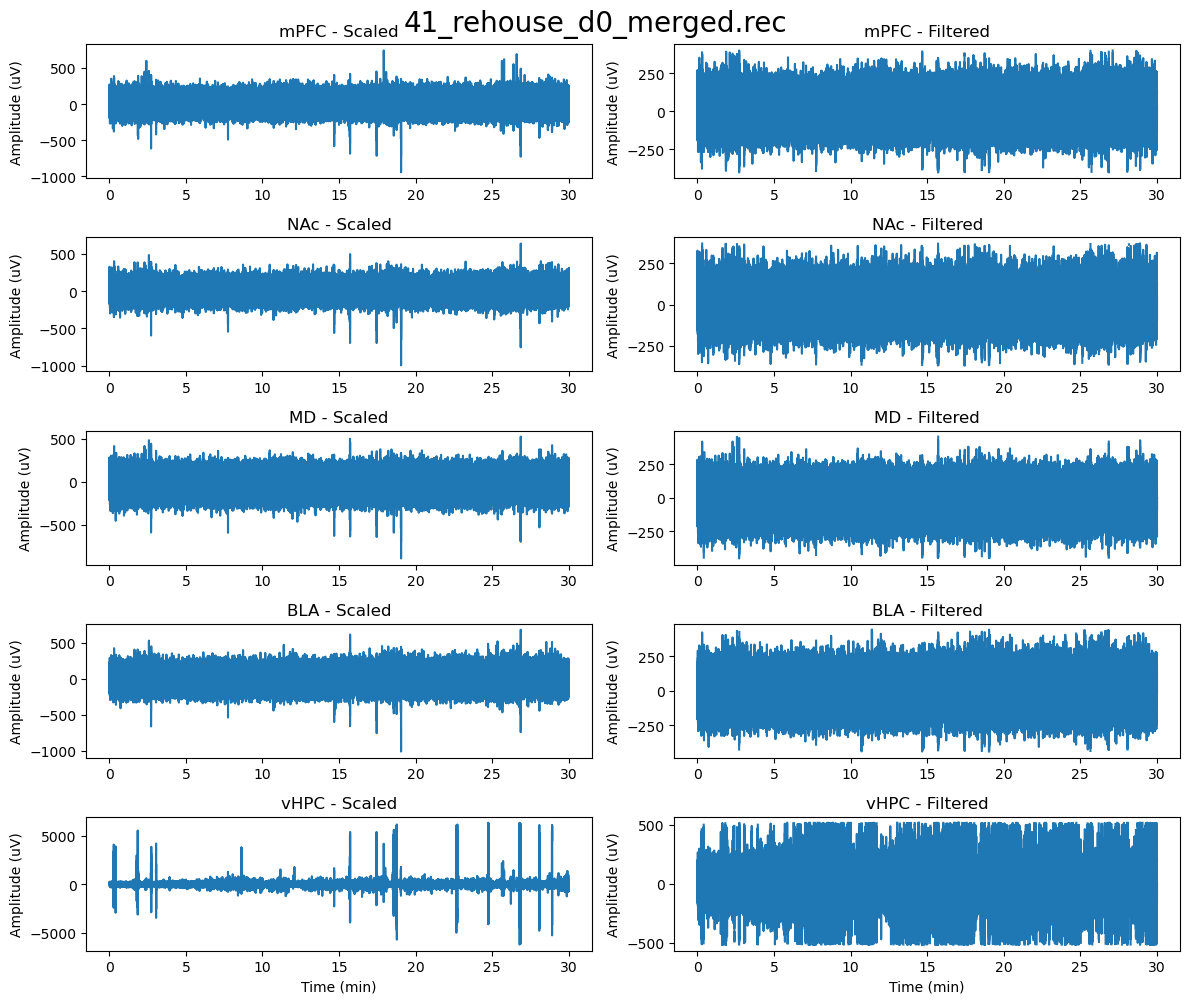

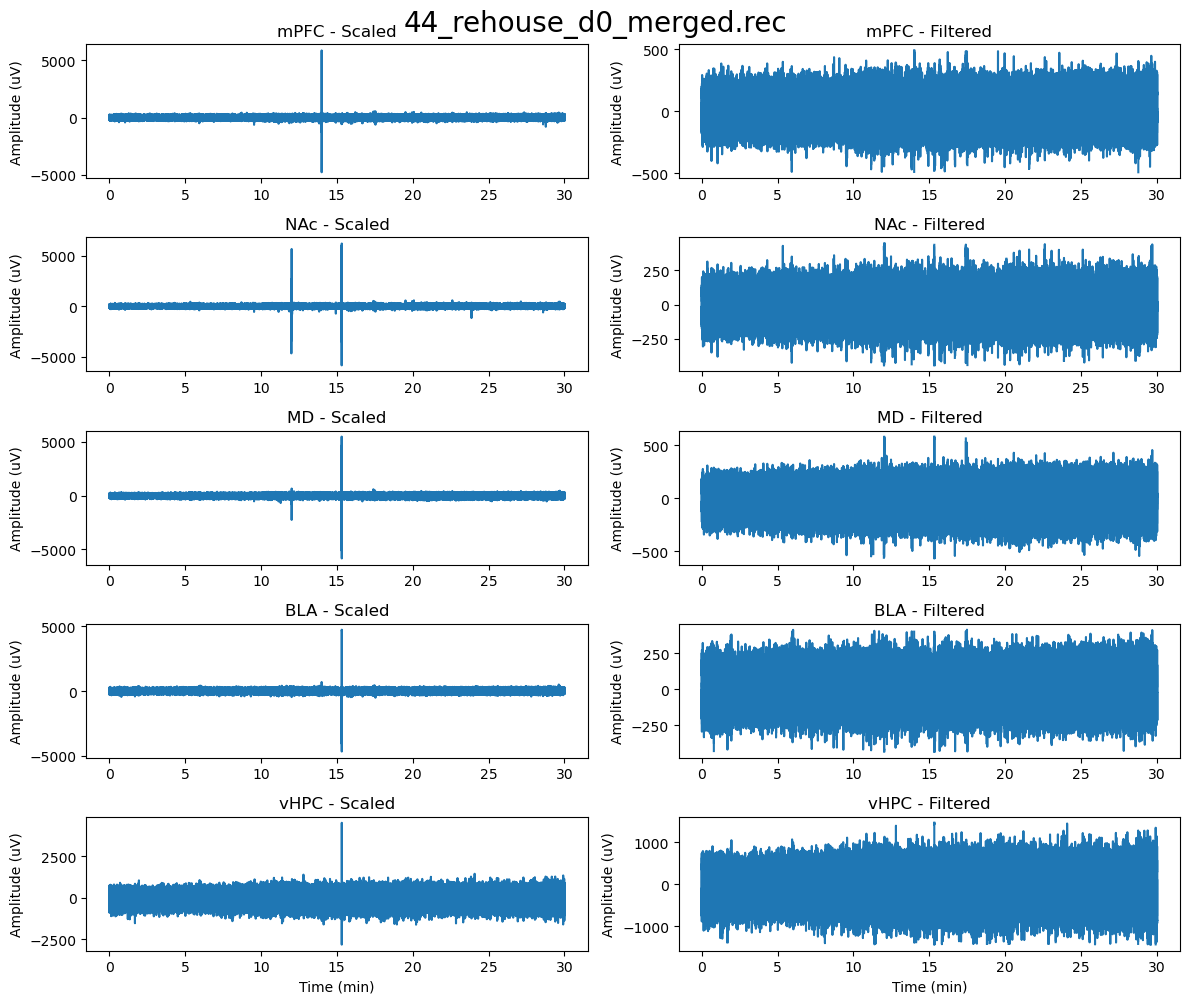

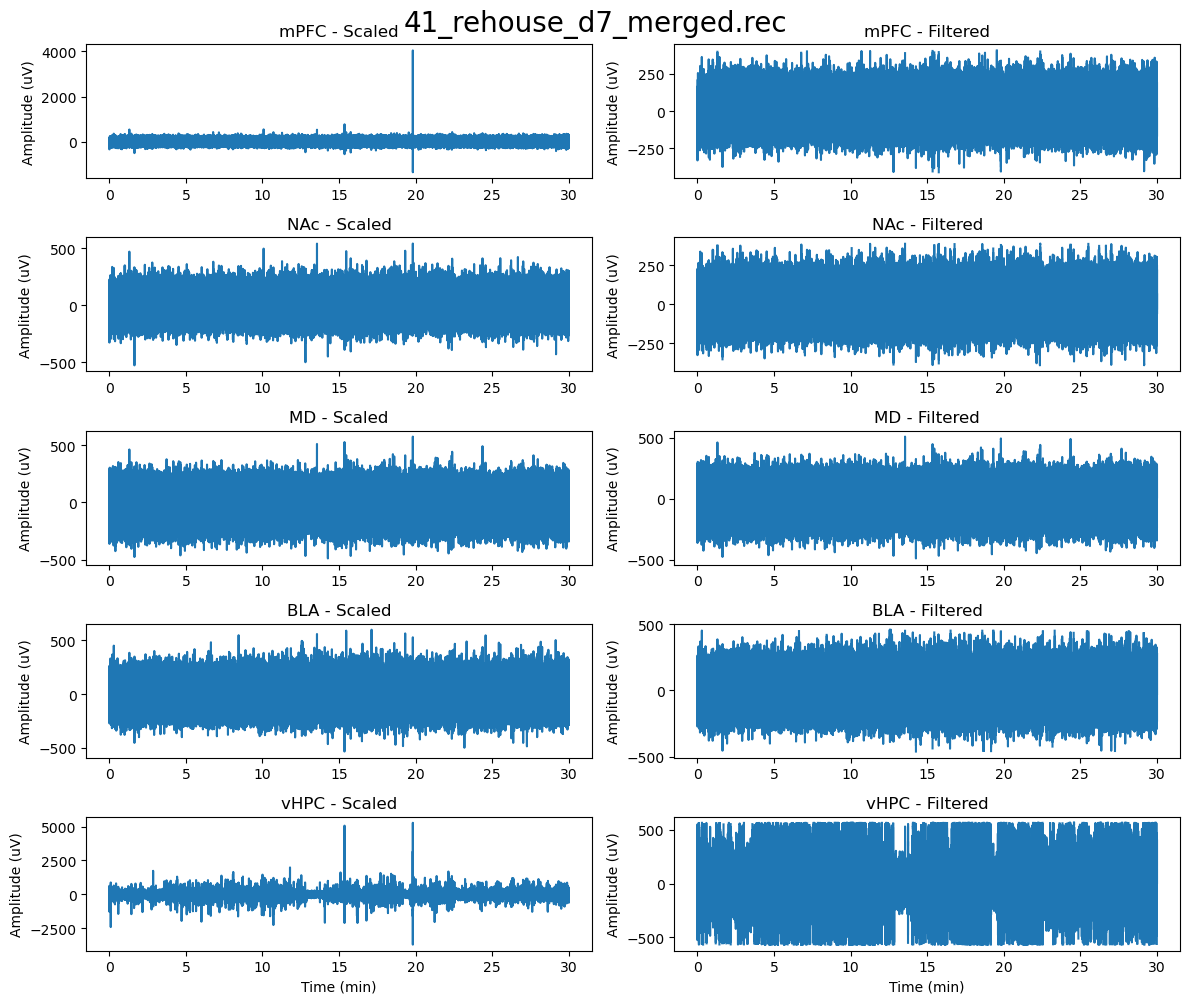

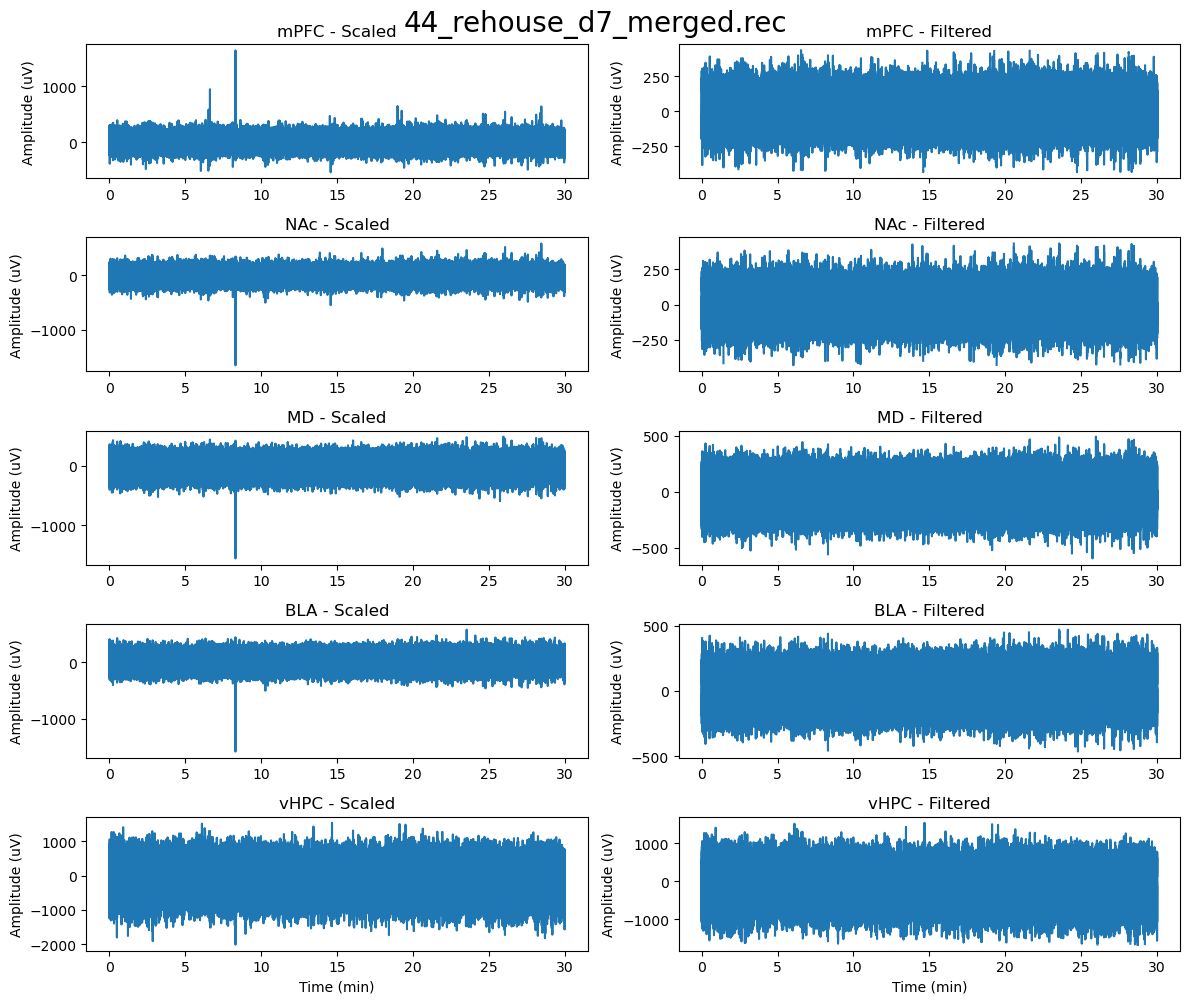

In [46]:
lfp_collection.diagnostic_plots(threshold=5)

In [47]:
# lfp_collection.diagnostic_plots_channel_finder()

### Saving collection to json+h5, saved to /home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/lfp_collections/aligned_lfpcollection_44_41

In [48]:
import json
import os

output_path = "/home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/lfp_collections"

notes = "Rehouse data - d0/d7 for subjs 41/44 - NAc is supposed to be bad for subject 44"

# creating output dir
os.makedirs(output_path, exist_ok=True)

# setting frequencies none so save works, consider changing class later for this to always be true
lfp_collection.frequencies = None


# === Save the collection ===
print(f"Saving LFPCollection to {output_path}...")
LFPCollection.save_to_json(
    lfp_collection,
    output_path=output_path,
    notes=notes,
    filename="aligned_lfpcollection_44_41"
)
print("✅ LFPCollection saved successfully to JSON + HDF5")


Saving LFPCollection to /home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/lfp_collections...
✅ LFPCollection saved successfully to JSON + HDF5


In [49]:
print(os.getcwd()) # this is why nbconvert isn't working, need to give full path somehow

/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys


In [50]:
!jupyter nbconvert --to script lfp_create_41_44_aligned.ipynb

[NbConvertApp] WARNING | pattern 'lfp_create_41_44_aligned.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
